# 01 — Exploratory Data Analysis

**Purpose**: confirm the Kaggle "Student Stress Factors: A Comprehensive Analysis" (rxnach) dataset matches what Chapter 2 of the dissertation describes, before any preprocessing or modelling work begins.

Research World only (`ml_pipeline/`) — no artifacts are produced by this notebook.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

DATA_PATH = "../datasets/raw/student_stress_factors.csv"
# Column name for the target/stress label. The published version of this
# dataset uses "stress_level" (0/1/2) — adjust if the downloaded file differs.
STRESS_LABEL_COL = "stress_level"

## Load dataset

In [2]:
df = pd.read_csv(DATA_PATH)
print(f"Shape: {df.shape}")
df.head()

Shape: (1100, 21)


,anxiety_level,self_esteem,mental_health_history,depression,headache,blood_pressure,sleep_quality,breathing_problem,noise_level,living_conditions,...,basic_needs,academic_performance,study_load,teacher_student_relationship,future_career_concerns,social_support,peer_pressure,extracurricular_activities,bullying,stress_level
0,14,20,0,11,2,1,2,4,2,3,...,2,3,2,3,3,2,3,3,2,1
1,15,8,1,15,5,3,1,4,3,1,...,2,1,4,1,5,1,4,5,5,2
2,12,18,1,14,2,1,2,2,2,2,...,2,2,3,3,2,2,3,2,2,1
3,16,12,1,15,4,3,1,3,4,2,...,2,2,4,1,4,1,4,4,5,2
4,16,28,0,7,2,3,5,1,3,2,...,3,4,3,1,2,1,5,0,5,1


## Data types

In [3]:
df.dtypes

anxiety_level                   int64
self_esteem                     int64
mental_health_history           int64
depression                      int64
headache                        int64
blood_pressure                  int64
sleep_quality                   int64
breathing_problem               int64
noise_level                     int64
living_conditions               int64
safety                          int64
basic_needs                     int64
academic_performance            int64
study_load                      int64
teacher_student_relationship    int64
future_career_concerns          int64
social_support                  int64
peer_pressure                   int64
extracurricular_activities      int64
bullying                        int64
stress_level                    int64
dtype: object

## Missing values

In [4]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct}).sort_values("missing_count", ascending=False)

,missing_count,missing_pct
anxiety_level,0,0.0
self_esteem,0,0.0
mental_health_history,0,0.0
depression,0,0.0
headache,0,0.0
blood_pressure,0,0.0
sleep_quality,0,0.0
breathing_problem,0,0.0
noise_level,0,0.0
living_conditions,0,0.0


## Class balance of the stress label

stress_level
0    373
2    369
1    358
Name: count, dtype: int64

stress_level
0    0.339
2    0.335
1    0.325
Name: proportion, dtype: float64


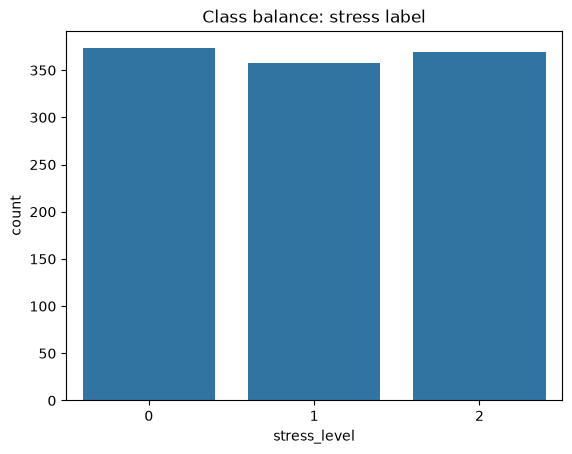

In [5]:
print(df[STRESS_LABEL_COL].value_counts())
print()
print(df[STRESS_LABEL_COL].value_counts(normalize=True).round(3))

sns.countplot(x=df[STRESS_LABEL_COL])
plt.title("Class balance: stress label")
plt.show()

## Correlation heatmap

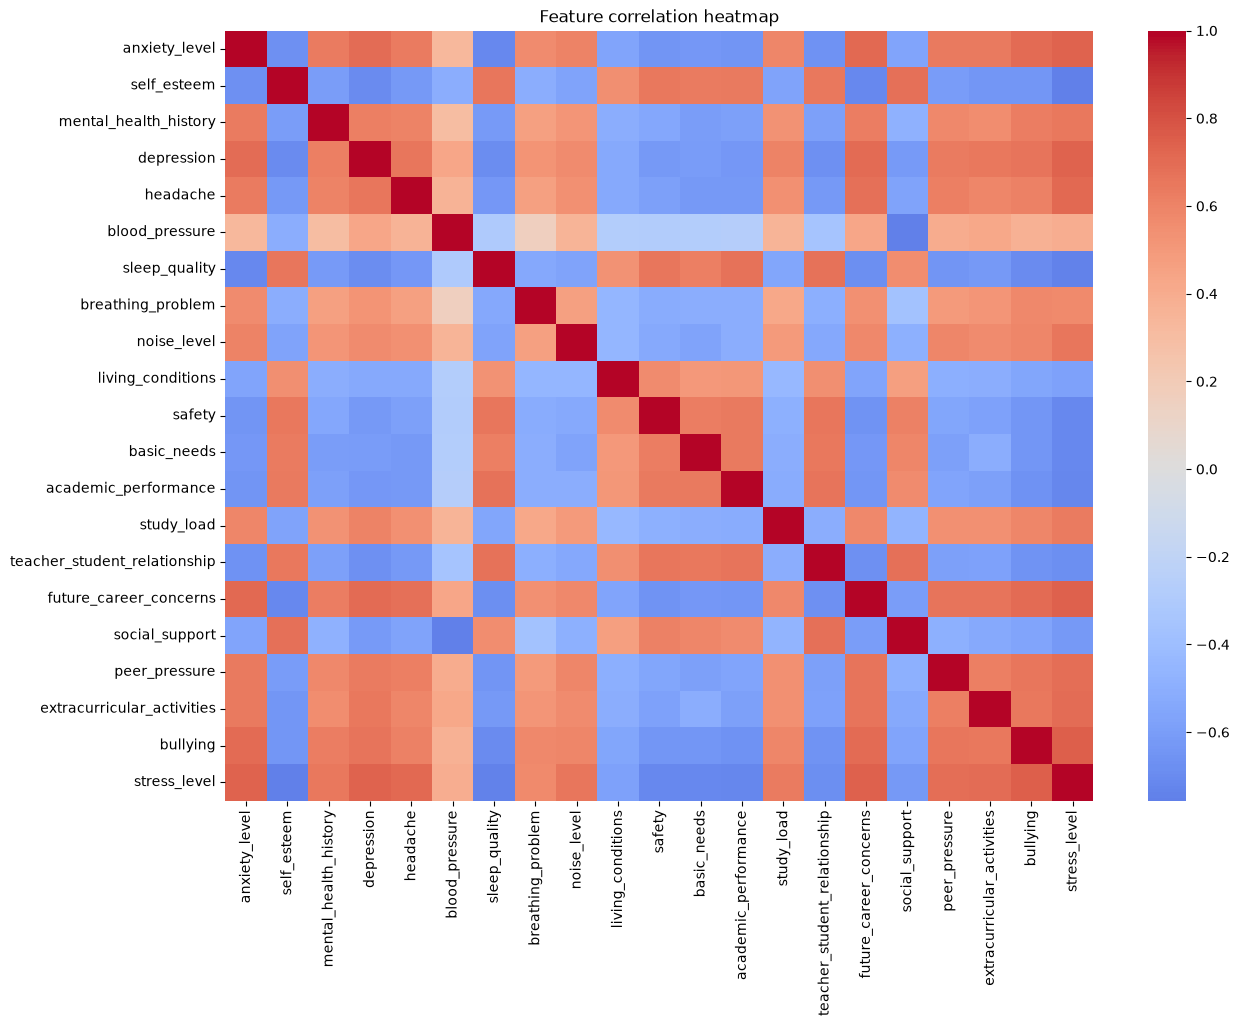

In [6]:
plt.figure(figsize=(14, 10))
sns.heatmap(df.corr(numeric_only=True), annot=False, cmap="coolwarm", center=0)
plt.title("Feature correlation heatmap")
plt.show()